<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/DeepLearning_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Perceptron implementation
# with bias term
import random
def perceptron(x,wt):
  f = x[0]
  for i,w in zip(x[1:],wt):
    f = f + (w*i)

  if f>=1:
    return 1
  else:
    return 0

x = [1 ,7.8, 2, 3, 6]
# wt = [1,1,1,1]
wt = random.sample(range(-2,2),4)
print("Random weights are ", wt)

print(perceptron(x,wt))

Random weights are  [1, -1, -2, 0]
0


In [ ]:
# Perceptron implementation
# with updated weights
import random
def perceptron(x,wt):
  f = x[0]
  for i,w in zip(x[1:],wt):
    w = w /10
    f = f + (w*i)

  if f>=1:
    return 1
  else:
    return 0

x = [1 , 7.8, 2, 3, 6]
# wt = [1,1,1,1]
wt = random.sample(range(-2,2),4)
print("Random weights are ", wt)

print(perceptron(x,wt))

Random weights are  [-2, 1, -1, 0]
0


In [ ]:
# Program for multiple instances

x2 = [1, 3, 5, 2, 8]
x3 = [1, 6.5, 1, 3, 5]
wt2 = random.sample(range(-2,2),4)
print("Random weights are ", wt2)
print(perceptron(x2, wt))
wt3 = random.sample(range(-2,2),4)
print("Random weights are ", wt3)
print(perceptron(x3, wt))

Random weights are  [-1, 1, -2, 0]
0
Random weights are  [-1, -2, 0, 1]
0


In [ ]:
#1.1 Design a simple perceptron with two inputs and random weights
import random

def perceptron(x, wt):
    f = 0
    for i, w in zip(x, wt):
        f += w * i
    if f >= 1:
        return 1
    else:
        return 0

x = [5, 0.2]
# wt = [-1, 1]
wt = random.sample(range(-1, 2), 2)
print('Random Weights are', wt)
perceptron(x, wt)

Random Weights are [-1, 1]


0

In [ ]:
# 1.2. Perceptron with multiple inputs and random weights
import random

def perceptron(x, wt):
    f = 0
    for i, w in zip(x, wt):
        w = w / 10  # Note: The code in your image scales the weight here
        f += w * i
    if f >= 1:
        return 1
    else:
        return 0

x = [7.8, 2, 2, 0.5]
# wt = [1, 1, 0, 1]
wt = random.sample(range(-1, 4), 4)
print('Random Weights are', wt)

perceptron(x, wt)

Random Weights are [1, 2, 0, -1]


1

In [ ]:
# 1.3. Verify whether the model correctly classified or not
import random

def perceptron(x, wt):
    f = 0
    for i, w in zip(x, wt):
        f += w * i
    if f >= 1:
        return 1
    else:
        return 0

x = [5, 0.2, 1]  # The last element '1' is the class label
print("x classified as =", x[2], "\n")

# wt = [1, -1]
wt = random.sample(range(-1, 2), 2)
print('Random Weights are', wt)

cls = perceptron(x, wt)
if cls == x[2]:
    print("correctly classified")
else:
    print("Incorrectly classified")
    cls = perceptron(x, wt) # Rerunning it (though weights haven't changed here)

x classified as = 1 

Random Weights are [-1, 1]
Incorrectly classified


In [ ]:
# 1.4. Perceptron (Prediction Logic)
# Make a prediction with weights
def predict(row, weights):
    activation = weights[0]
    for i in range(len(row)-1):
        activation += weights[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

# test predictions of action and horror features
dataset = [[2,2,0],
           [1,2,0],
           [5,4,1],
           [2,1,0],
           [3,3,1],
           [7,2,1],
           [5,2,1],
           [6,1,1],
           [8,-0.2,1],
           [7,3,1]]

weights = [-0.4, 0.099999999999999992, 0.100000000000000003] # Exact values from image

for row in dataset:
    prediction = predict(row, weights)
    print("Expected=%d, Predicted=%d" % (row[-1], prediction))

Expected=0, Predicted=0
Expected=0, Predicted=0
Expected=1, Predicted=1
Expected=0, Predicted=0
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1


In [ ]:
# 1.5. Implement a perceptron to classify a movie by training the weights with stochastic gradient descent
# Make a prediction with wt; Estimate weights with Stochastic gradient descent
def predict(row, wt):
    activation = wt[0]
    for i in range(len(row)-1):
        activation += wt[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

# Estimate Perceptron wt using stochastic gradient descent
def train_wt(train, l_rate, n_turn):
    wt = [0.0 for i in range(len(train[0]))]
    for turn in range(n_turn):
        sum_error = 0.0
        for row in train:
            prediction = predict(row, wt)
            error = row[-1] - prediction
            sum_error += error**2
            wt[0] = wt[0] + l_rate * error
            for i in range(len(row)-1):
                wt[i + 1] = wt[i + 1] + l_rate * error * row[i]
        print('>turn=%d, lrate=%.3f, error=%.3f' % (turn, l_rate, sum_error))
    return wt

# Calculate wt
dataset = [[2,2,0],
           [1,2,0],
           [5,4,1],
           [2,1,0],
           [3,3,1],
           [7,2,1],
           [5,2,1],
           [6,1,1],
           [8,-0.2,1],
           [7,3,1]]

l_rate = 0.1
n_turn = 4

wt = train_wt(dataset, l_rate, n_turn)
print(wt)

for row in dataset:
    prediction = predict(row, wt)
    print("Expected=%d, Predicted=%d" % (row[-1], prediction))

>turn=0, lrate=0.100, error=3.000
>turn=1, lrate=0.100, error=3.000
>turn=2, lrate=0.100, error=3.000
>turn=3, lrate=0.100, error=1.000
[-0.4, 0.09999999999999992, 0.10000000000000003]
Expected=0, Predicted=0
Expected=0, Predicted=0
Expected=1, Predicted=1
Expected=0, Predicted=0
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1
Expected=1, Predicted=1


Starting Experiment 1: Comparison...
Training Perceptron (Doc 1 Code)...
Training Feed Forward Network (Doc 4 Code)...


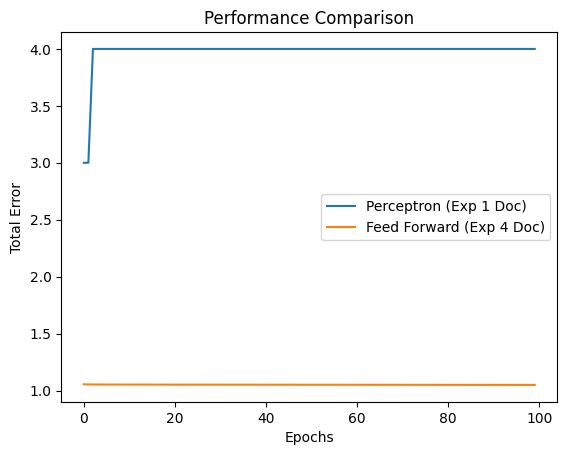

In [1]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# PART A: CODE FROM EXPT 1 DOC (Perceptron)
# ==========================================
def predict_perceptron(row, weights):
    activation = weights[0] # Bias
    for i in range(len(row)-1):
        activation += weights[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

def train_perceptron(train, l_rate, n_epoch):
    # Initialize weights: 1 bias + n_inputs
    weights = [0.0 for i in range(len(train[0]))]
    history = []

    for epoch in range(n_epoch):
        sum_error = 0.0
        for row in train:
            prediction = predict_perceptron(row, weights)
            error = row[-1] - prediction
            sum_error += error**2
            weights[0] = weights[0] + l_rate * error
            for i in range(len(row)-1):
                weights[i + 1] = weights[i + 1] + l_rate * error * row[i]
        history.append(sum_error)
    return history

# ==========================================
# PART B: CODE FROM EXPT 4 DOC (Feed Forward)
# ==========================================
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1]
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

def train_feedforward(network, train, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# ==========================================
# PART C: THE EXPERIMENT (Comparing Them)
# ==========================================

# 1. The Dataset (XOR Problem - Hard for Perceptron, Easy for FeedForward)
# Input: [A, B, Bias(ignored)], Output: A XOR B
dataset = [
    [0,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0]
]

print("Starting Experiment 1: Comparison...")

# 2. Train Perceptron (From Doc 1)
print("Training Perceptron (Doc 1 Code)...")
perceptron_errors = train_perceptron(dataset, 0.1, 100)

# 3. Train Feed Forward (From Doc 4)
print("Training Feed Forward Network (Doc 4 Code)...")
ff_network = initialize_network(2, 2, 1) # 2 Inputs -> 2 Hidden -> 1 Output
ff_errors = train_feedforward(ff_network, dataset, 0.5, 100)

# 4. Plot Results
plt.plot(perceptron_errors, label='Perceptron (Exp 1 Doc)')
plt.plot(ff_errors, label='Feed Forward (Exp 4 Doc)')
plt.title('Performance Comparison')
plt.xlabel('Epochs')
plt.ylabel('Total Error')
plt.legend()
plt.show()

Running Experiment 1: Optimizer Deep Dive...
Training with Standard SGD...
Training with Momentum...


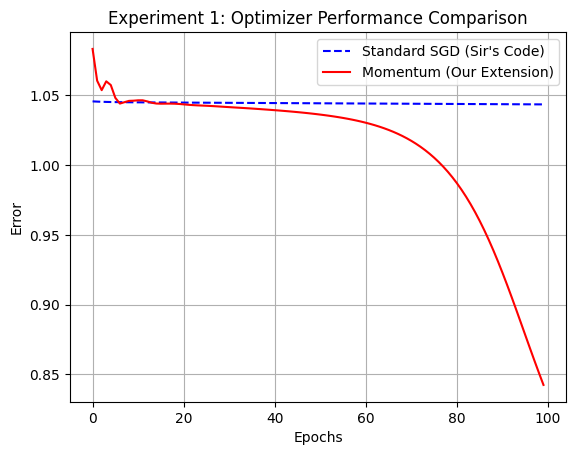

In [2]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Sir's Code from Expt4)
# ==========================================
# We use the exact structure provided in the document
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)], 'velocity': [0.0]*(n_inputs+1)} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)], 'velocity': [0.0]*(n_hidden+1)} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias is the last weight
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# ==========================================
# 2. THE OPTIMIZERS (The "Different Optimizers" Task)
# ==========================================

# OPTIMIZER A: Standard SGD (Strictly from Sir's Doc)
def update_weights_sgd(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta'] # Bias

# OPTIMIZER B: Momentum (Our Custom "Deep Dive" Code)
# Logic: weight = weight + (velocity * momentum) + (learning_rate * error * input)
def update_weights_momentum(network, row, l_rate, momentum=0.9):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            # Update Weights with Momentum
            for j in range(len(inputs)):
                # Calculate the "push" from the current error
                current_push = l_rate * neuron['delta'] * inputs[j]
                # Combine with old velocity
                neuron['velocity'][j] = (momentum * neuron['velocity'][j]) + current_push
                # Apply to weight
                neuron['weights'][j] += neuron['velocity'][j]

            # Update Bias with Momentum
            current_push_bias = l_rate * neuron['delta']
            neuron['velocity'][-1] = (momentum * neuron['velocity'][-1]) + current_push_bias
            neuron['weights'][-1] += neuron['velocity'][-1]

# ==========================================
# 3. THE TRAINING LOOP (Comparing Performance)
# ==========================================
def train_network(optimizer_type, dataset, l_rate, n_epoch):
    # Re-initialize network every time so both start fresh
    network = initialize_network(2, 2, 1)
    error_history = []

    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)

            # SWITCH: Choose the optimizer
            if optimizer_type == 'sgd':
                update_weights_sgd(network, row, l_rate)
            elif optimizer_type == 'momentum':
                update_weights_momentum(network, row, l_rate, momentum=0.9)

            sum_error += (expected[0] - network[-1][0]['output'])**2
        error_history.append(sum_error)
    return error_history

# ==========================================
# 4. EXECUTION
# ==========================================
# Dataset: XOR Problem (0,0->0 | 0,1->1 | 1,0->1 | 1,1->0)
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

print("Running Experiment 1: Optimizer Deep Dive...")

# Run 1: Standard SGD
print("Training with Standard SGD...")
sgd_errors = train_network('sgd', dataset, l_rate=0.5, n_epoch=100)

# Run 2: Momentum
print("Training with Momentum...")
momentum_errors = train_network('momentum', dataset, l_rate=0.5, n_epoch=100)

# Plotting the "Performance Measure"
plt.plot(sgd_errors, label='Standard SGD (Sir\'s Code)', color='blue', linestyle='--')
plt.plot(momentum_errors, label='Momentum (Our Extension)', color='red')
plt.title('Experiment 1: Optimizer Performance Comparison')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

Running Experiment 1: Optimizer Deep Dive...
Training with Standard SGD...
Training with Momentum...


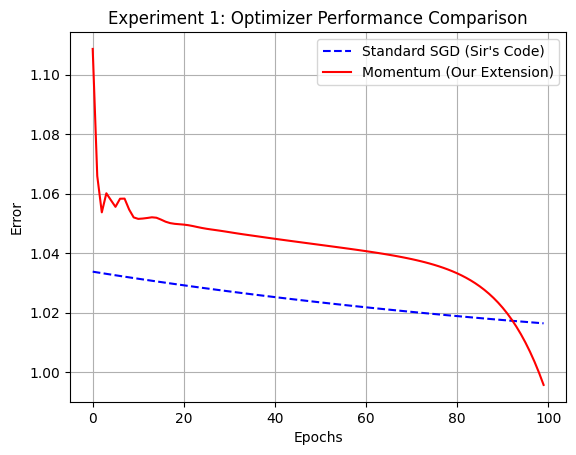

In [3]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Sir's Code from Expt4)
# ==========================================
# We use the exact structure provided in the document
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)], 'velocity': [0.0]*(n_inputs+1)} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)], 'velocity': [0.0]*(n_hidden+1)} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias is the last weight
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# ==========================================
# 2. THE OPTIMIZERS (The "Different Optimizers" Task)
# ==========================================

# OPTIMIZER A: Standard SGD (Strictly from Sir's Doc)
def update_weights_sgd(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta'] # Bias

# OPTIMIZER B: Momentum (Our Custom "Deep Dive" Code)
# Logic: weight = weight + (velocity * momentum) + (learning_rate * error * input)
def update_weights_momentum(network, row, l_rate, momentum=0.9):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            # Update Weights with Momentum
            for j in range(len(inputs)):
                # Calculate the "push" from the current error
                current_push = l_rate * neuron['delta'] * inputs[j]
                # Combine with old velocity
                neuron['velocity'][j] = (momentum * neuron['velocity'][j]) + current_push
                # Apply to weight
                neuron['weights'][j] += neuron['velocity'][j]

            # Update Bias with Momentum
            current_push_bias = l_rate * neuron['delta']
            neuron['velocity'][-1] = (momentum * neuron['velocity'][-1]) + current_push_bias
            neuron['weights'][-1] += neuron['velocity'][-1]

# ==========================================
# 3. THE TRAINING LOOP (Comparing Performance)
# ==========================================
def train_network(optimizer_type, dataset, l_rate, n_epoch):
    # Re-initialize network every time so both start fresh
    network = initialize_network(2, 2, 1)
    error_history = []

    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)

            # SWITCH: Choose the optimizer
            if optimizer_type == 'sgd':
                update_weights_sgd(network, row, l_rate)
            elif optimizer_type == 'momentum':
                update_weights_momentum(network, row, l_rate, momentum=0.9)

            sum_error += (expected[0] - network[-1][0]['output'])**2
        error_history.append(sum_error)
    return error_history

# ==========================================
# 4. EXECUTION
# ==========================================
# Dataset: XOR Problem (0,0->0 | 0,1->1 | 1,0->1 | 1,1->0)
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

print("Running Experiment 1: Optimizer Deep Dive...")

# Run 1: Standard SGD
print("Training with Standard SGD...")
sgd_errors = train_network('sgd', dataset, l_rate=0.01, n_epoch=100)

# Run 2: Momentum
print("Training with Momentum...")
momentum_errors = train_network('momentum', dataset, l_rate=0.5, n_epoch=100)

# Plotting the "Performance Measure"
plt.plot(sgd_errors, label='Standard SGD (Sir\'s Code)', color='blue', linestyle='--')
plt.plot(momentum_errors, label='Momentum (Our Extension)', color='red')
plt.title('Experiment 1: Optimizer Performance Comparison')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

Running Experiment 1: Optimizer Deep Dive...
Training with Standard SGD...
Training with Momentum...


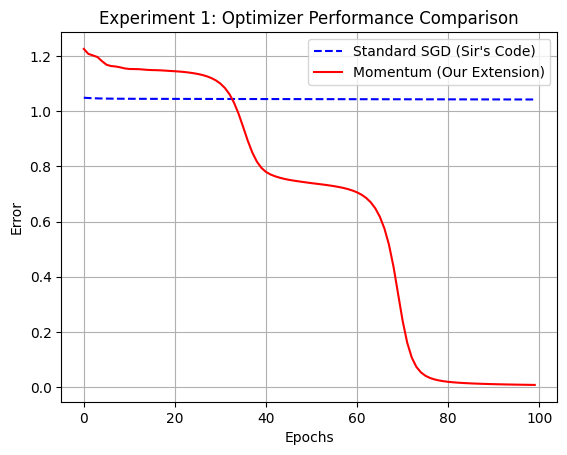

In [4]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Sir's Code from Expt4)
# ==========================================
# We use the exact structure provided in the document
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)], 'velocity': [0.0]*(n_inputs+1)} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)], 'velocity': [0.0]*(n_hidden+1)} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias is the last weight
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# ==========================================
# 2. THE OPTIMIZERS (The "Different Optimizers" Task)
# ==========================================

# OPTIMIZER A: Standard SGD (Strictly from Sir's Doc)
def update_weights_sgd(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta'] # Bias

# OPTIMIZER B: Momentum (Our Custom "Deep Dive" Code)
# Logic: weight = weight + (velocity * momentum) + (learning_rate * error * input)
def update_weights_momentum(network, row, l_rate, momentum=0.9):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            # Update Weights with Momentum
            for j in range(len(inputs)):
                # Calculate the "push" from the current error
                current_push = l_rate * neuron['delta'] * inputs[j]
                # Combine with old velocity
                neuron['velocity'][j] = (momentum * neuron['velocity'][j]) + current_push
                # Apply to weight
                neuron['weights'][j] += neuron['velocity'][j]

            # Update Bias with Momentum
            current_push_bias = l_rate * neuron['delta']
            neuron['velocity'][-1] = (momentum * neuron['velocity'][-1]) + current_push_bias
            neuron['weights'][-1] += neuron['velocity'][-1]

# ==========================================
# 3. THE TRAINING LOOP (Comparing Performance)
# ==========================================
def train_network(optimizer_type, dataset, l_rate, n_epoch):
    # Re-initialize network every time so both start fresh
    network = initialize_network(2, 2, 1)
    error_history = []

    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)

            # SWITCH: Choose the optimizer
            if optimizer_type == 'sgd':
                update_weights_sgd(network, row, l_rate)
            elif optimizer_type == 'momentum':
                update_weights_momentum(network, row, l_rate, momentum=0.9)

            sum_error += (expected[0] - network[-1][0]['output'])**2
        error_history.append(sum_error)
    return error_history

# ==========================================
# 4. EXECUTION
# ==========================================
# Dataset: XOR Problem (0,0->0 | 0,1->1 | 1,0->1 | 1,1->0)
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

print("Running Experiment 1: Optimizer Deep Dive...")

# Run 1: Standard SGD
print("Training with Standard SGD...")
sgd_errors = train_network('sgd', dataset, l_rate=0.5, n_epoch=100)

# Run 2: Momentum
print("Training with Momentum...")
momentum_errors = train_network('momentum', dataset, l_rate=2.0, n_epoch=100)

# Plotting the "Performance Measure"
plt.plot(sgd_errors, label='Standard SGD (Sir\'s Code)', color='blue', linestyle='--')
plt.plot(momentum_errors, label='Momentum (Our Extension)', color='red')
plt.title('Experiment 1: Optimizer Performance Comparison')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()